## <span style="color:blue"> Lezione 10 </span>



In [11]:

import matplotlib.pyplot as plt


import numpy as np

parent_folder="l_10_all_es/"

### <span style="color:DodgerBlue"> Esercizio 10.1-10.2 </span>



L'esercizio riprende dall'algoritmo genetico della lezione precedente ed implementa una parallelizzazione di esso su $T$ core. 

Ogni core porta avanti una popolazione, che evolve in modo separato dalle altre. Ogni $S$ generazioni, però, i core si scambiano l'individuo migliore della loro popolazione. L'ordine dello scambio è dettato da una permutazione casuale $P$ di $[1,...,T]$: ogni core riceve dall'individuo alla propria sinistra e manda all'individuo alla propria destra in $P$ (con condizioni periodiche al contorno).

Il codice è stato testato con $T=11$ core sulle $R=110$ province italiane, caricate nella cella sottosante, con $M=3000$ individui per generazione, $N=2500$ generazioni, e migrazioni ogni $S=200$ generazioni.

In [12]:

cities=np.loadtxt(f"{parent_folder}cap_prov_ita.dat")


Nella cella seguente vengono caricati i risultati.

In [13]:

N_cores=11

cols=range(3,3 + len(cities)+1) #per leggere i percorsi: salta le prime tre colonne (gen, avg_len,len) e il percorso è lungo N_cities + 1



#per ogni core
best_paths=[]#salva il miglior percorso in assoluto
best_lenghts=[]#salva la lunghezza del miglior percorso per ogni generazione
avg_lenghts=[]#salva la lunghezza media della metà migliore della popolazione per ogni generazione


for i in range(N_cores): 

    filename=f"W_MIGR/rank_{i}_pop.csv"
    avg_len,best_len=np.loadtxt(f"{parent_folder}{filename}",usecols=(1,2),unpack=True,skiprows=1)
    best_lenghts.append(best_len)
    avg_lenghts.append(avg_len)

    best_paths.append(np.loadtxt(f"{parent_folder}{filename}",usecols=cols,skiprows=(len(best_lenghts[0]))))#carica solo l'ultimo percorso (il migliore di tutti)

  


gen=np.arange(1,len(best_lenghts[0])+1)



Nella cella sottostante, vengono graficati i risultati.

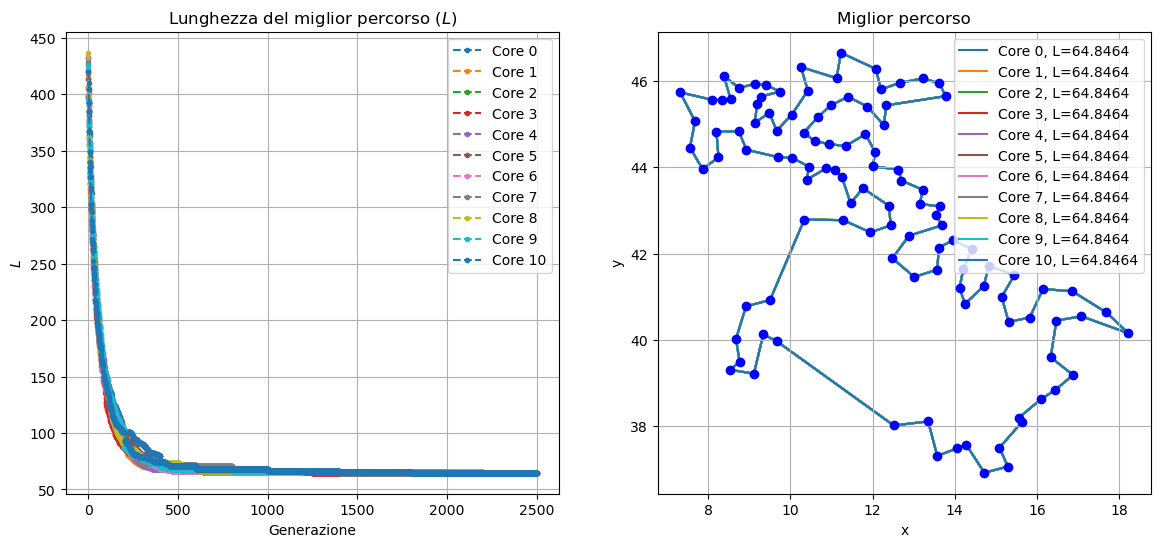

In [14]:
fig,axs=plt.subplots(1,2,figsize=[14,6])
axs[1].scatter(cities[:,0],cities[:,1],color="blue",zorder=2)#città 

for i,best_path in enumerate(best_paths):
    axs[0].plot(gen,best_lenghts[i],"--.",label=f"Core {i}")
    #axs[0].plot(gen,avg_lenghts[i],"--.",label=f"Core {i}, avg")

    index=best_path.astype(int)#ordine in cui le città vengono visitate (percorso migliore)
    axs[1].plot(cities[index,0],cities[index,1],zorder=1,label=f"Core {i}, L={best_lenghts[i][-1]:.4f}") #unisce le città nell'ordine in cui vengono visitate




axs[0].grid()
axs[0].set_xlabel("Generazione")
axs[0].set_ylabel(r"$L$")
axs[0].set_title(r"Lunghezza del miglior percorso ($L$)")
axs[0].legend()





axs[1].grid()
axs[1].set_xlabel("x")
axs[1].set_ylabel("y")
axs[1].set_title("Miglior percorso")
axs[1].legend();

Nelle celle sottostanti vengono caricati e graficati i dati ottenuti applicando l'algoritmo con le stesse $R=110$ città, gli stessi $T=11$ core, le stesse $N=2500$ generazioni da $M=3000$ individui ciascuna, ma senza permettere agli individui di migrare tra i core.

In [19]:

N_cores=11

cols=range(3,3 + len(cities)+1) #per leggere i percorsi: salta le prime tre colonne (gen, avg_len,len) e il percorso è lungo N_cities + 1



#per ogni core
NM_best_paths=[]#salva il miglior percorso in assoluto
NM_best_lenghts=[]#salva la lunghezza del miglior percorso per ogni generazione
NM_avg_lenghts=[]#salva la lunghezza media della metà migliore della popolazione per ogni generazione


for i in range(N_cores): 

    filename=f"NO_MIGR/rank_{i}_pop.csv"
    avg_len,best_len=np.loadtxt(f"{parent_folder}{filename}",usecols=(1,2),unpack=True,skiprows=1)
    NM_best_lenghts.append(best_len)
    NM_avg_lenghts.append(avg_len)

    NM_best_paths.append(np.loadtxt(f"{parent_folder}{filename}",usecols=cols,skiprows=(len(best_lenghts[0]))))#carica solo l'ultimo percorso (il migliore di tutti)

  



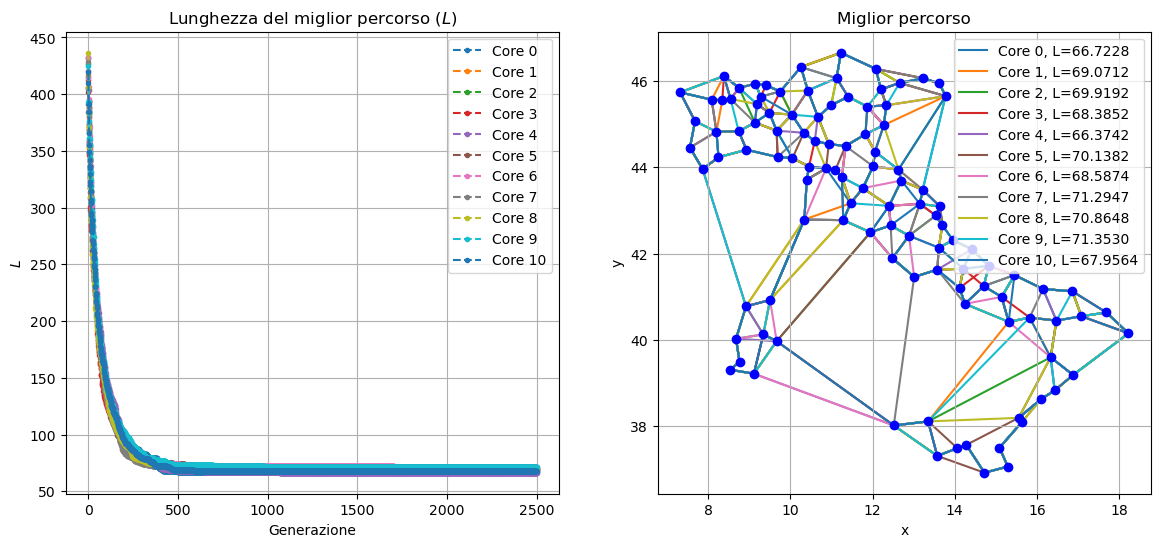

In [20]:
fig,axs=plt.subplots(1,2,figsize=[14,6])
axs[1].scatter(cities[:,0],cities[:,1],color="blue",zorder=2)#città 

for i,best_path in enumerate(NM_best_paths):
    axs[0].plot(gen,NM_best_lenghts[i],"--.",label=f"Core {i}")
    #axs[0].plot(gen,avg_lenghts[i],"--.",label=f"Core {i}, avg")

    index=best_path.astype(int)#ordine in cui le città vengono visitate (percorso migliore)
    axs[1].plot(cities[index,0],cities[index,1],zorder=1,label=f"Core {i}, L={NM_best_lenghts[i][-1]:.4f}") #unisce le città nell'ordine in cui vengono visitate




axs[0].grid()
axs[0].set_xlabel("Generazione")
axs[0].set_ylabel(r"$L$")
axs[0].set_title(r"Lunghezza del miglior percorso ($L$)")
axs[0].legend()





axs[1].grid()
axs[1].set_xlabel("x")
axs[1].set_ylabel("y")
axs[1].set_title("Miglior percorso")
axs[1].legend();

Con lo stesso numero di individui e di generazioni del caso precedente, l'algoritmo non converge ad una soluzione. È dunque evidente che la presenza delle migrazioni è un aiuto alla convergenza dell'algoritmo.